
Scholarship descriptions kept:
descr
LGS SCHOLARSHIP-TUITION           601
Sum LGS SCHOLARSHIP-TUITION       246
LGS-MDP-COVERDELL-FELLOWSH         38
LGS-BIOETH-Shields-SCHOLARSHIP      6
LGS-MDP-Sheth-SCHOLARSHIP           5
LGS-MDP-Whatcom-Scholarship         4
SumLGS-BIOETH-Shields-SCHOLAR       1
LGS Scholarship-TU-HHS              1
LGS-CSMS-NEMATI-SUPPORT             1
LGS-MDP-IDN-SCHOLARSHIP             1
SumLGS-CSMS-NEMATI-SUPPORT          1
Name: count, dtype: int64

Program summary:
                program  students  avg_tuition  avg_scholarship  \
0                   MDP       135   108,230.99        59,519.39   
1      Computer Science       154    65,700.89        32,250.42   
2             Bioethics        68    53,545.27         5,124.66   
3    Cancer Biology 4+1        28    61,501.07        15,930.86   
4         Bioethics 4+1        27    45,221.70         7,199.00   
5                  Math        19    57,857.68        23,709.58   
6          Data Science        

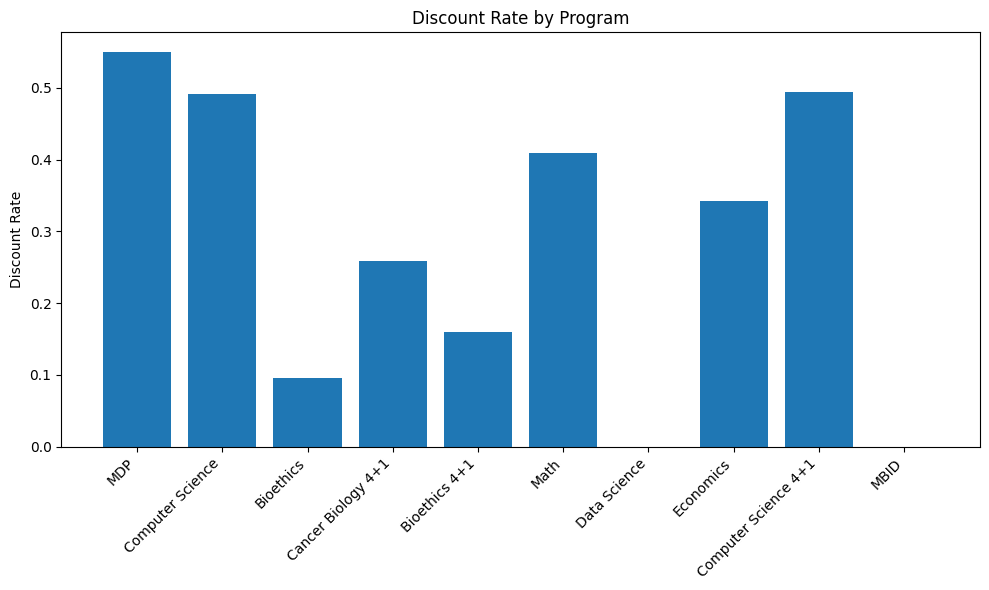

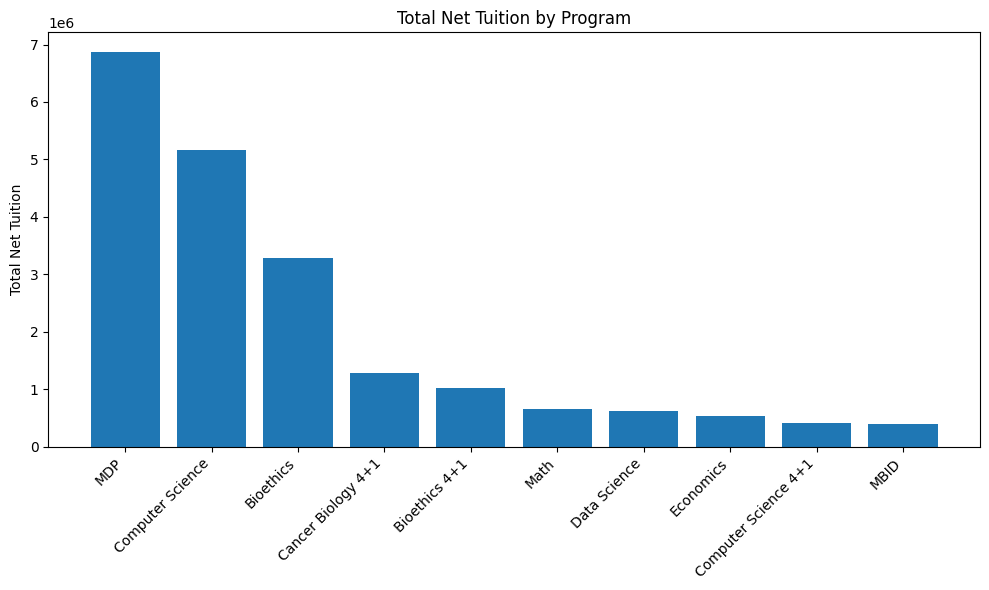

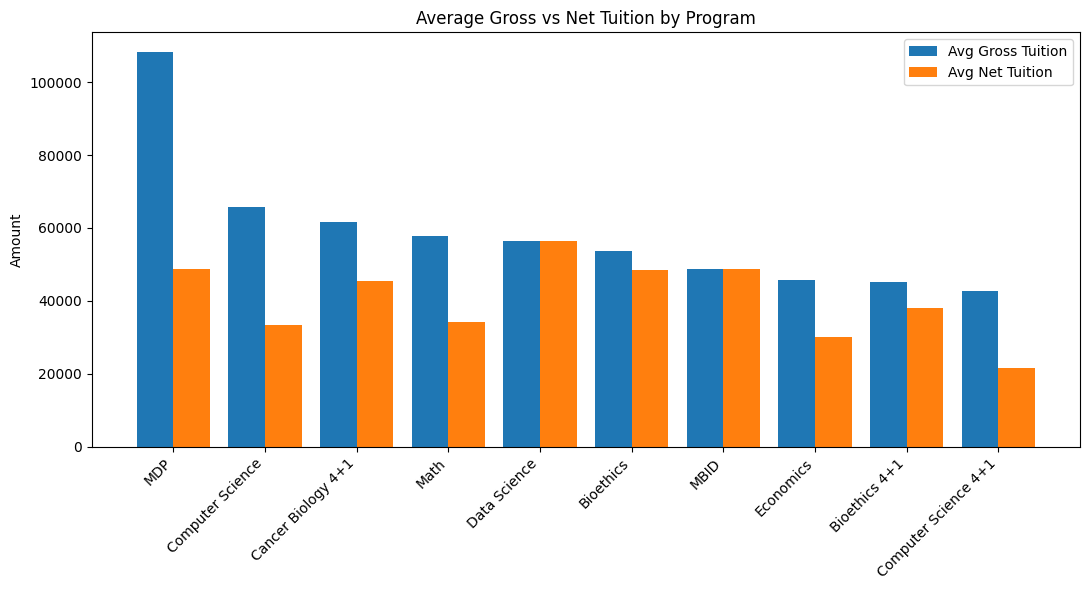


Saved:
- program_summary_output.xlsx
- student_program_level_output.xlsx
- student_program_year_output.xlsx


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
file_path = "Tuition Data.xlsx"

tuition = pd.read_excel(file_path, sheet_name="Gross Tuition Billed to Student")
scholarship = pd.read_excel(file_path, sheet_name="Tuition Scholarship given to st")

tuition.columns = tuition.columns.str.strip()
scholarship.columns = scholarship.columns.str.strip()

# ----------------------------
# ACADEMIC YEAR HELPER
# ----------------------------
# Emory PeopleSoft term codes: 5YYS where YY = last 2 digits of calendar year
# and S = season (1=Spring, 6=Summer, 9=Fall). Academic year end-year matches
# the scholarship sheet's "Aid Yr" convention: Fall 2018 + Spring 2019 +
# Summer 2019 all roll up to AY end-year 2019.
def term_to_academic_year(code):
    code = int(code)
    y = 2000 + (code // 10) % 100
    s = code % 10
    return y + 1 if s == 9 else y

# ----------------------------
# CLEAN TUITION DATA
# ----------------------------
tuition = tuition.rename(columns={
    "Gross Tuition": "tuition",
    "Acad Plan": "acad_plan",
    "Item Term": "term_code",
})

tuition = tuition[["ID", "acad_plan", "term_code", "tuition"]].copy()
tuition["tuition"] = pd.to_numeric(tuition["tuition"], errors="coerce")
tuition = tuition.dropna(subset=["acad_plan", "tuition"])
tuition["academic_year"] = tuition["term_code"].apply(term_to_academic_year)

# ----------------------------
# CLEAN SCHOLARSHIP DATA
# ----------------------------
scholarship = scholarship.rename(columns={
    "Academic Plan": "acad_plan",
    "Descr": "descr",
    "Fall Tuition Scholarship": "fall_sch",
    "Spring Tuiiton Scholarship": "spring_sch",
    "Summer Tuition Scholarship": "summer_sch",
    "Aid Yr": "academic_year",
})

for col in ["fall_sch", "spring_sch", "summer_sch"]:
    scholarship[col] = pd.to_numeric(scholarship[col], errors="coerce").fillna(0)

scholarship["scholarship"] = (
    scholarship["fall_sch"] + scholarship["spring_sch"] + scholarship["summer_sch"]
)
scholarship["academic_year"] = pd.to_numeric(scholarship["academic_year"], errors="coerce").astype("Int64")

scholarship = scholarship[["ID", "acad_plan", "descr", "scholarship", "academic_year"]].copy()

# ----------------------------
# PROGRAM MAP
# ----------------------------
program_map = {
    "COMPSCIMS": "Computer Science",
    "CS4P1MS": "Computer Science 4+1",
    "DATASCIMS": "Data Science",
    "QTMMS": "Data Science",
    "ECONMS": "Economics",
    "ECON4P1MS": "Economics",
    "MATHMS": "Math",
    "BIOETHMA": "Bioethics",
    "BIOETH4P1": "Bioethics 4+1",
    "DEVPRACMDP": "MDP",
    "HUMANRTCRT": "MDP",
    "BMIDMS": "MBID",
    "BBS4P1MS": "Cancer Biology 4+1",
}

# Terms per academic year per plan. Sources: Information Sheet
# (Comp Sci / Math / CS 4+1 / Econ 4+1 = Fall-Spring; Econ MS = Summer-Fall-Spring;
# Data Sciences MS = Fall-Spring-Summer) + empirical seasonal distribution for
# programs the Information Sheet does not list.
terms_per_year = {
    "COMPSCIMS": 2, "CS4P1MS": 2, "MATHMS": 2,
    "ECON4P1MS": 2, "BIOETHMA": 2, "BIOETH4P1": 2, "BMIDMS": 2,
    "ECONMS": 3, "DATASCIMS": 3, "QTMMS": 3,
    "DEVPRACMDP": 3, "HUMANRTCRT": 3, "BBS4P1MS": 3,
}

tuition = tuition[tuition["acad_plan"].isin(program_map.keys())].copy()
scholarship = scholarship[scholarship["acad_plan"].isin(program_map.keys())].copy()

# ----------------------------
# FILTER SCHOLARSHIPS
# ----------------------------
exclude_terms = [
    "nih", "nsf", "grfp", "training grant", "special-scholarship",
    "yellow ribbon", "vet", "americorps", "pell", "hope", "zell",
    "woodruff scholar-grad tuition",
]

def keep_scholarship(descr):
    if pd.isna(descr):
        return False
    d = str(descr).lower().strip()
    if any(term in d for term in exclude_terms):
        return False
    return "lgs" in d

scholarship = scholarship[scholarship["descr"].apply(keep_scholarship)].copy()

print("\nScholarship descriptions kept:")
print(scholarship["descr"].value_counts().head(30))

# ----------------------------
# AGGREGATE TO STUDENT-PROGRAM-YEAR LEVEL (df_year)
# ----------------------------
tuition_year = (
    tuition.groupby(["ID", "acad_plan", "academic_year"], as_index=False)
    .agg(tuition=("tuition", "sum"),
         term_count=("tuition", "count"))
)

scholarship_year = (
    scholarship.groupby(["ID", "acad_plan", "academic_year"], as_index=False)["scholarship"].sum()
)

df_year = pd.merge(
    tuition_year, scholarship_year,
    on=["ID", "acad_plan", "academic_year"], how="left",
)
df_year["scholarship"] = df_year["scholarship"].fillna(0)
df_year["program"] = df_year["acad_plan"].map(program_map)
df_year["net_tuition"] = (df_year["tuition"] - df_year["scholarship"]).clip(lower=0)

# ----------------------------
# COLLAPSE TO STUDENT-PROGRAM LEVEL (df)
# ----------------------------
df = (
    df_year.groupby(["ID", "acad_plan"], as_index=False)
    .agg(tuition=("tuition", "sum"),
         scholarship=("scholarship", "sum"),
         term_count=("term_count", "sum"),
         first_ay=("academic_year", "min"),
         last_ay=("academic_year", "max"),
         ay_count=("academic_year", "nunique"))
)
df["program"] = df["acad_plan"].map(program_map)
df["net_tuition"] = (df["tuition"] - df["scholarship"]).clip(lower=0)

# ----------------------------
# PROGRAM-LEVEL SUMMARY
# ----------------------------
program_summary = (
    df.groupby("program", as_index=False)
    .agg(
        students=("ID", "nunique"),
        avg_tuition=("tuition", "mean"),
        avg_scholarship=("scholarship", "mean"),
        avg_net_tuition=("net_tuition", "mean"),
        total_gross_tuition=("tuition", "sum"),
        total_scholarship=("scholarship", "sum"),
        total_net_tuition=("net_tuition", "sum"),
    )
)

program_summary["discount_rate"] = (
    program_summary["total_scholarship"] / program_summary["total_gross_tuition"]
)

program_summary = program_summary.sort_values(
    by="total_net_tuition", ascending=False
).reset_index(drop=True)

pd.options.display.float_format = "{:,.2f}".format

print("\nProgram summary:")
print(program_summary)

# ----------------------------
# CHART 1: DISCOUNT RATE BY PROGRAM
# ----------------------------
plt.figure(figsize=(10, 6))
plt.bar(program_summary["program"], program_summary["discount_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Discount Rate by Program")
plt.ylabel("Discount Rate")
plt.tight_layout()
plt.show()

# ----------------------------
# CHART 2: TOTAL NET TUITION BY PROGRAM
# ----------------------------
plt.figure(figsize=(10, 6))
plt.bar(program_summary["program"], program_summary["total_net_tuition"])
plt.xticks(rotation=45, ha="right")
plt.title("Total Net Tuition by Program")
plt.ylabel("Total Net Tuition")
plt.tight_layout()
plt.show()

# ----------------------------
# CHART 3: AVG GROSS VS AVG NET TUITION
# ----------------------------
plot_df = program_summary.sort_values("avg_tuition", ascending=False)

x = range(len(plot_df))
width = 0.4

plt.figure(figsize=(11, 6))
plt.bar([i - width/2 for i in x], plot_df["avg_tuition"], width=width, label="Avg Gross Tuition")
plt.bar([i + width/2 for i in x], plot_df["avg_net_tuition"], width=width, label="Avg Net Tuition")
plt.xticks(list(x), plot_df["program"], rotation=45, ha="right")
plt.title("Average Gross vs Net Tuition by Program")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# SAVE OUTPUT
# ----------------------------
program_summary.to_excel("program_summary_output.xlsx", index=False)
df.to_excel("student_program_level_output.xlsx", index=False)
df_year.to_excel("student_program_year_output.xlsx", index=False)

print("\nSaved:")
print("- program_summary_output.xlsx")
print("- student_program_level_output.xlsx")
print("- student_program_year_output.xlsx")


In [2]:
print(tuition.columns)
print(scholarship.columns)

Index(['ID', 'acad_plan', 'term_code', 'tuition', 'academic_year'], dtype='str')
Index(['ID', 'acad_plan', 'descr', 'scholarship', 'academic_year'], dtype='str')


In [3]:
# ----------------------------
# ADD INTERNATIONAL STUDENT %
# ----------------------------

# reload scholarship sheet so we can use the demographic column cleanly
scholarship_full = pd.read_excel(file_path, sheet_name="Tuition Scholarship given to st")
scholarship_full.columns = scholarship_full.columns.str.strip()

scholarship_full = scholarship_full.rename(columns={
    "Academic Plan": "acad_plan"
})

# keep only programs in your analysis
scholarship_full = scholarship_full[scholarship_full["acad_plan"].isin(program_map.keys())].copy()

# create international flag
scholarship_full["intl"] = scholarship_full["EU CC IPEDS"].apply(
    lambda x: 1 if str(x).strip() == "Non US Citizen" else 0
)

# one row per student-program
intl_df = scholarship_full.groupby(["ID", "acad_plan"], as_index=False)["intl"].max()

# merge into your existing df
df = pd.merge(df, intl_df, on=["ID", "acad_plan"], how="left")
df["intl"] = df["intl"].fillna(0)

# rebuild program summary with intl counts
program_summary = (
    df.groupby("program", as_index=False)
    .agg(
        students=("ID", "nunique"),
        intl_students=("intl", "sum"),
        avg_tuition=("tuition", "mean"),
        avg_scholarship=("scholarship", "mean"),
        avg_net_tuition=("net_tuition", "mean"),
        total_gross_tuition=("tuition", "sum"),
        total_scholarship=("scholarship", "sum"),
        total_net_tuition=("net_tuition", "sum")
    )
)

program_summary["discount_rate"] = (
    program_summary["total_scholarship"] / program_summary["total_gross_tuition"]
)

program_summary["intl_pct"] = (
    program_summary["intl_students"] / program_summary["students"]
)

program_summary = program_summary.sort_values(
    by="total_net_tuition",
    ascending=False
).reset_index(drop=True)

print(program_summary[[
    "program", "students", "intl_students", "intl_pct",
    "avg_tuition", "avg_scholarship", "avg_net_tuition", "discount_rate"
]])

program_summary["intl_pct"] = program_summary["intl_pct"] * 100
program_summary["discount_rate"] = program_summary["discount_rate"] * 100

print(program_summary[[
    "program", "students", "intl_students", "intl_pct", "discount_rate"
]])

# ----------------------------
# PRICING-FOCUSED FILTER (df_pricing)
# ----------------------------
# Exclude student-program rows with total billed tuition under $20,000.
# A non-trivial minority of students appear in the feed with only a
# partial-term or single-course billing (total career tuition in the
# ~$500-$10k range). These rows distort pricing analysis two ways:
#   (1) they drag avg_tuition and avg_net_tuition downward because the
#       student was never billed a full program load to begin with;
#   (2) they almost always carry $0 kept LGS scholarship, which pulls
#       the aggregate discount_rate artificially low and compresses the
#       gross-vs-net gap for a typical full-load student.
# $20k sits below any full-year sticker price in the program set but
# well above partial-term billings, so it isolates the "real" pricing
# population. df_pricing is used ONLY for the three pricing-focused
# outputs (discount rate by program, avg gross vs net tuition, peer
# benchmark). Enrollment counts, the international mix scatter, and the
# per-year trend charts continue to run on the full df / df_year so the
# student population is not understated.

df_pricing = df[df["tuition"] >= 20000].copy()

pricing_summary = (
    df_pricing.groupby("program", as_index=False)
    .agg(
        students=("ID", "nunique"),
        avg_tuition=("tuition", "mean"),
        avg_scholarship=("scholarship", "mean"),
        avg_net_tuition=("net_tuition", "mean"),
        total_gross_tuition=("tuition", "sum"),
        total_scholarship=("scholarship", "sum"),
        total_net_tuition=("net_tuition", "sum"),
    )
)
pricing_summary["discount_rate"] = (
    pricing_summary["total_scholarship"] / pricing_summary["total_gross_tuition"] * 100
)
pricing_summary = pricing_summary.sort_values(
    by="total_net_tuition", ascending=False
).reset_index(drop=True)

print("\nPricing summary (df_pricing, tuition >= $20k):")
print(pricing_summary)

# ----------------------------
# RE-SAVE: two tabs in program_summary_output.xlsx
#   - program_summary: full population (all counts, intl mix)
#   - pricing_summary: df_pricing-based pricing metrics
# ----------------------------
with pd.ExcelWriter("program_summary_output.xlsx", engine="openpyxl") as writer:
    program_summary.to_excel(writer, sheet_name="program_summary", index=False)
    pricing_summary.to_excel(writer, sheet_name="pricing_summary", index=False)
df.to_excel("student_program_level_output.xlsx", index=False)


                program  students  intl_students  intl_pct  avg_tuition  \
0                   MDP       135          39.00      0.29   108,230.99   
1      Computer Science       154         133.00      0.86    65,700.89   
2             Bioethics        68           0.00      0.00    53,545.27   
3    Cancer Biology 4+1        28           4.00      0.14    61,501.07   
4         Bioethics 4+1        27           2.00      0.07    45,221.70   
5                  Math        19           8.00      0.42    57,857.68   
6          Data Science        11           0.00      0.00    56,451.64   
7             Economics        18           5.00      0.28    45,588.89   
8  Computer Science 4+1        19           5.00      0.26    42,788.63   
9                  MBID         8           0.00      0.00    48,800.00   

   avg_scholarship  avg_net_tuition  discount_rate  
0        59,519.39        48,711.60           0.55  
1        32,250.42        33,479.88           0.49  
2         5,124

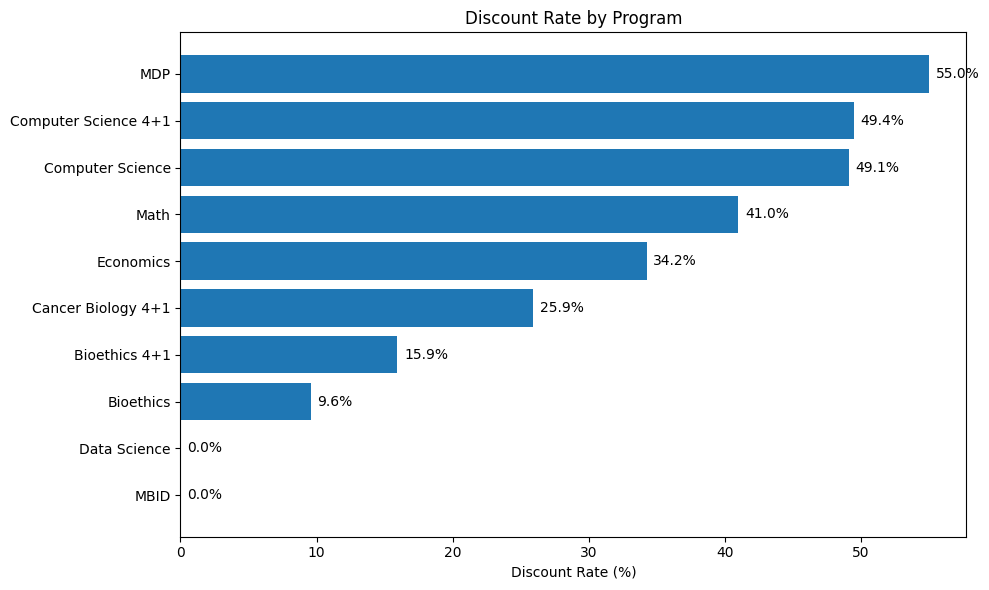

In [4]:
import matplotlib.pyplot as plt

plot_df = program_summary.sort_values("discount_rate", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(plot_df["program"], plot_df["discount_rate"])
plt.xlabel("Discount Rate (%)")
plt.title("Discount Rate by Program")
plt.gca().invert_yaxis()

for i, v in enumerate(plot_df["discount_rate"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

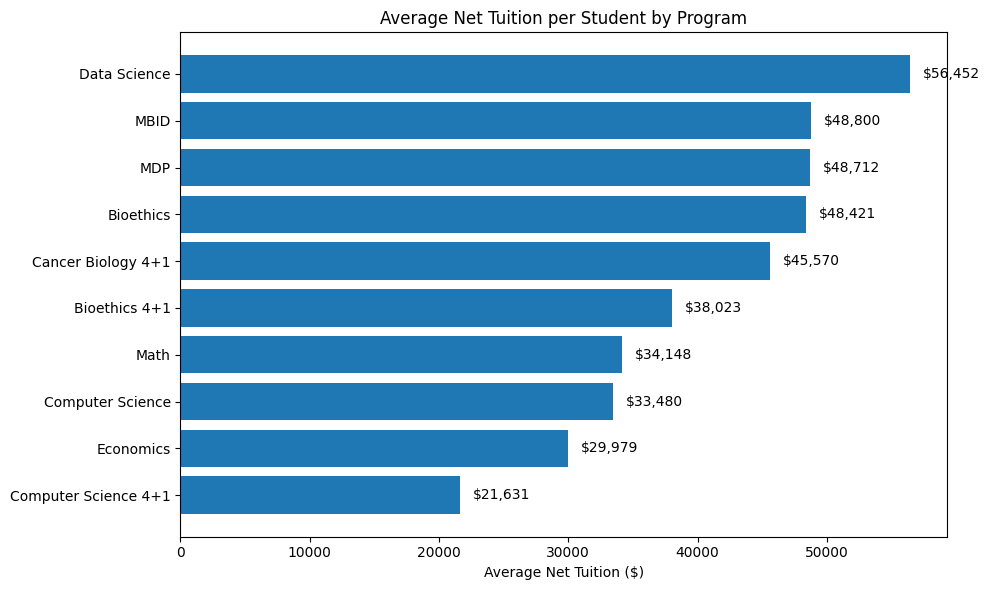

In [5]:
plot_df = program_summary.sort_values("avg_net_tuition", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(plot_df["program"], plot_df["avg_net_tuition"])
plt.xlabel("Average Net Tuition ($)")
plt.title("Average Net Tuition per Student by Program")
plt.gca().invert_yaxis()

for i, v in enumerate(plot_df["avg_net_tuition"]):
    plt.text(v + 1000, i, f"${v:,.0f}", va='center')

plt.tight_layout()
plt.show()

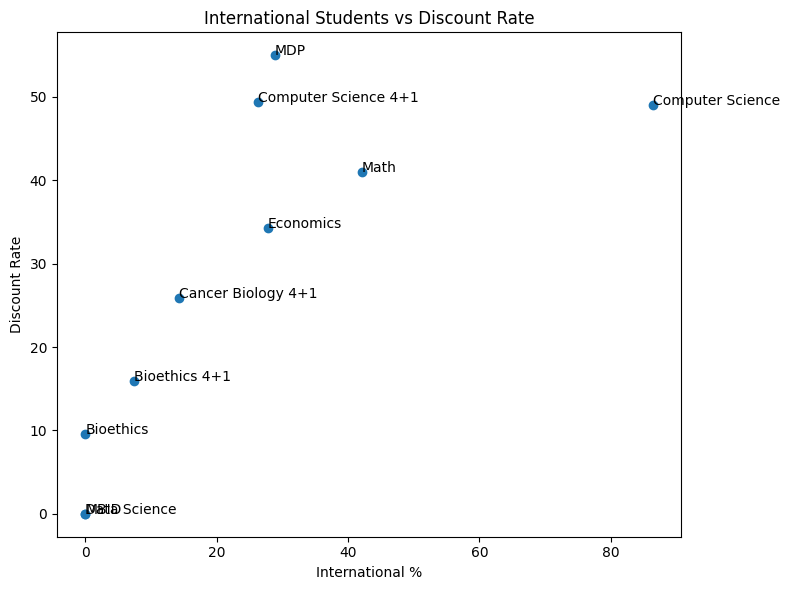

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(program_summary["intl_pct"], program_summary["discount_rate"])

for i, row in program_summary.iterrows():
    plt.text(row["intl_pct"], row["discount_rate"], row["program"])

plt.xlabel("International %")
plt.ylabel("Discount Rate")
plt.title("International Students vs Discount Rate")

plt.tight_layout()
plt.show()

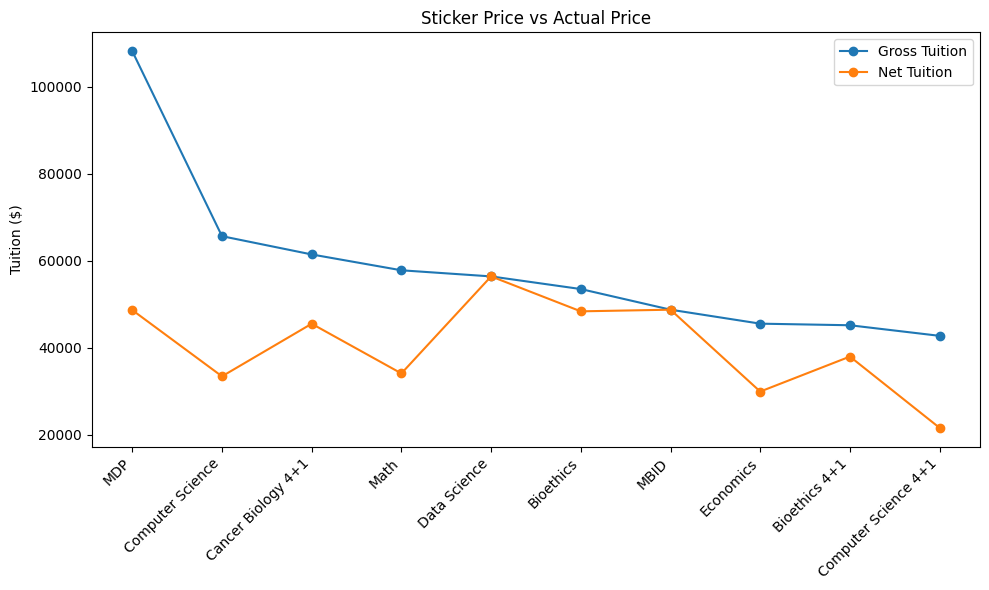

In [7]:
plot_df = program_summary.sort_values("avg_tuition", ascending=False)

plt.figure(figsize=(10,6))

plt.plot(plot_df["program"], plot_df["avg_tuition"], marker='o', label="Gross Tuition")
plt.plot(plot_df["program"], plot_df["avg_net_tuition"], marker='o', label="Net Tuition")

plt.xticks(rotation=45, ha='right')
plt.ylabel("Tuition ($)")
plt.title("Sticker Price vs Actual Price")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
peer_data = pd.DataFrame([
    # DATA / CS
    {"school": "Columbia", "program_group": "Data/CS", "tuition": 64800},
    {"school": "NYU", "program_group": "Data/CS", "tuition": 75750},
    {"school": "Georgia Tech", "program_group": "Data/CS", "tuition": 39500},

    # ECON
    {"school": "Columbia", "program_group": "Economics", "tuition": 90732},
    {"school": "NYU", "program_group": "Economics", "tuition": 70000},
    {"school": "Georgia Tech", "program_group": "Economics", "tuition": 41390},

    # GENERAL
    {"school": "Columbia", "program_group": "General", "tuition": 73456},
    {"school": "NYU", "program_group": "General", "tuition": 70000},
    {"school": "Georgia Tech", "program_group": "General", "tuition": 31210},
])

In [9]:
# ----------------------------
# GROSS TUITION (ANNUALIZED BY PROGRAM TERMS-PER-YEAR)
# ----------------------------
# Uses the `terms_per_year` dict from cell 0 so each student's total billed
# tuition is annualized using the structure of their actual program
# (Info Sheet + empirical), not a blanket 2-term assumption.

tuition_gross = pd.read_excel(file_path, sheet_name="Gross Tuition Billed to Student")
tuition_gross.columns = tuition_gross.columns.str.strip()

tuition_gross = tuition_gross.rename(columns={
    "Gross Tuition": "tuition",
    "Acad Plan": "acad_plan",
})

tuition_gross = tuition_gross[["ID", "acad_plan", "tuition"]].copy()
tuition_gross["tuition"] = pd.to_numeric(tuition_gross["tuition"], errors="coerce")
tuition_gross = tuition_gross.dropna(subset=["acad_plan", "tuition"])

tuition_gross = tuition_gross[tuition_gross["acad_plan"].isin(program_map.keys())].copy()
tuition_gross["program"] = tuition_gross["acad_plan"].map(program_map)
tuition_gross["terms_per_year"] = tuition_gross["acad_plan"].map(terms_per_year)

# ----------------------------
# STEP 1: STUDENT × PLAN ANNUALIZATION
# Preserves acad_plan so terms_per_year is applied correctly even within
# merged program buckets (e.g. Economics contains both ECONMS=3 and ECON4P1MS=2).
# ----------------------------
student_program = (
    tuition_gross.groupby(["ID", "acad_plan", "program"], as_index=False)
    .agg(total_tuition=("tuition", "sum"),
         term_count=("tuition", "count"),
         terms_per_year=("terms_per_year", "first"))
)

student_program["annual_tuition"] = (
    student_program["total_tuition"] * student_program["terms_per_year"] / student_program["term_count"]
)

# ----------------------------
# STEP 2: PROGRAM-LEVEL AVERAGE
# ----------------------------
program_summary_gross = (
    student_program.groupby("program", as_index=False)
    .agg(students=("ID", "nunique"),
         avg_tuition=("annual_tuition", "mean"))
)

# ----------------------------
# PROGRAM GROUPING (for peer comparison)
# ----------------------------
def map_group(program):
    p = program.lower()
    if any(x in p for x in ["computer", "data"]):
        return "Data/CS"
    elif any(x in p for x in ["econ", "math"]):
        return "Economics"
    else:
        return "General"

emory_grouped_gross = program_summary_gross.copy()
emory_grouped_gross["program_group"] = emory_grouped_gross["program"].apply(map_group)

# ----------------------------
# GROUP LEVEL (FINAL EMORY NUMBERS)
# ----------------------------
emory_group_summary = (
    emory_grouped_gross.groupby("program_group", as_index=False)
    .agg(tuition=("avg_tuition", "mean"))
)

emory_group_summary["school"] = "Emory"

# ----------------------------
# COMBINE WITH PEERS
# ----------------------------
combined = pd.concat([
    peer_data,
    emory_group_summary[["school", "program_group", "tuition"]],
], ignore_index=True)


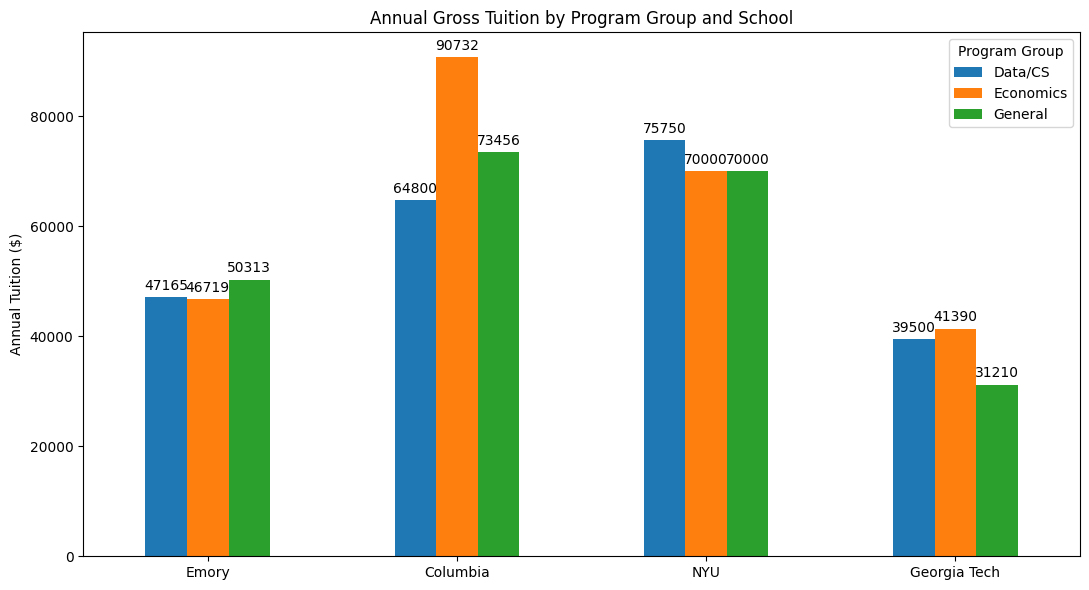

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# COMBINE EMORY + PEERS
# ----------------------------
combined = pd.concat([
    peer_data,
    emory_group_summary[["school", "program_group", "tuition"]]
], ignore_index=True)

# make sure order is consistent
school_order = ["Emory", "Columbia", "NYU", "Georgia Tech"]
group_order = ["Data/CS", "Economics", "General"]

combined["school"] = pd.Categorical(combined["school"], categories=school_order, ordered=True)
combined["program_group"] = pd.Categorical(combined["program_group"], categories=group_order, ordered=True)

# pivot for grouped bar chart
pivot = combined.pivot(index="school", columns="program_group", values="tuition")
pivot = pivot.loc[school_order, group_order]

# ----------------------------
# PLOT
# ----------------------------
ax = pivot.plot(kind="bar", figsize=(11, 6))

plt.title("Annual Gross Tuition by Program Group and School")
plt.ylabel("Annual Tuition ($)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Program Group")
plt.tight_layout()

# add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.show()

In [11]:
print(tuition_gross.head(20))

         ID acad_plan   tuition    program  terms_per_year
0     39261  BIOETHMA    464.40  Bioethics               2
1    391080  BIOETHMA  9,288.00  Bioethics               2
2    398337  BIOETHMA  4,644.00  Bioethics               2
3   1605332  BIOETHMA 25,000.00  Bioethics               2
4   1823126  BIOETHMA 20,900.00  Bioethics               2
5   1849711  BIOETHMA 20,900.00  Bioethics               2
6   1911122  BIOETHMA  9,288.00  Bioethics               2
7   1949008  BIOETHMA  6,966.00  Bioethics               2
8   2150241  BIOETHMA 20,900.00  Bioethics               2
10  2152681  BIOETHMA 11,610.00  Bioethics               2
11  2222027  BIOETHMA 20,900.00  Bioethics               2
13  2298904  BIOETHMA 20,900.00  Bioethics               2
14  2326431  BIOETHMA 20,900.00  Bioethics               2
15  2335810  BIOETHMA 20,900.00  Bioethics               2
16    39261  BIOETHMA  2,322.00  Bioethics               2
17   358409  BIOETHMA  2,322.00  Bioethics              